In [19]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

try:
    path = fetch("data/retail_demand.csv")
except NameError:
    path = "data/retail_demand.csv"

SEED = 42
np.random.seed(SEED)


## 1. Time Series Structure & Diagnostics

Rows after filtering: 1096
Duplicate dates: 0
2023-01-01 00:00:00 to 2025-12-31 00:00:00
Missing: 0
Remaining NaN: 0


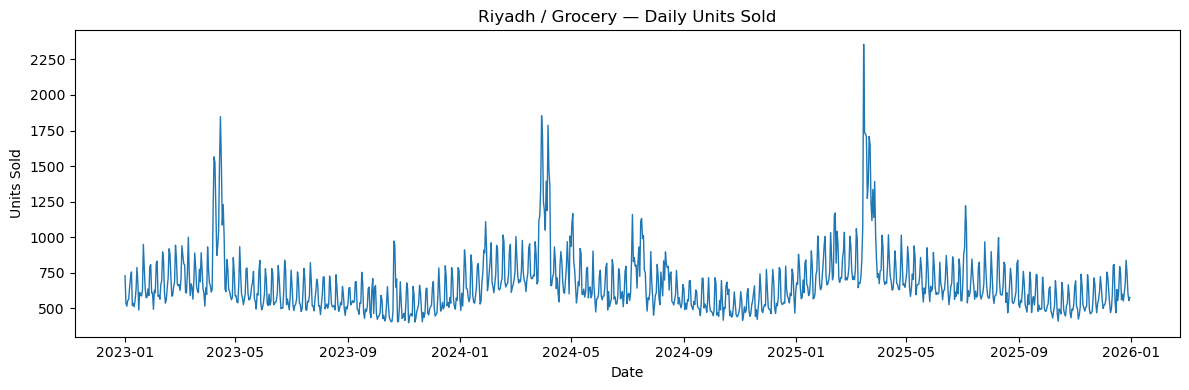

In [20]:
df = pd.read_csv("retail_demand.csv")

# Convert date to datetime
df["date"] = pd.to_datetime(df["date"])

# Filter
riyadh_grocery = df[
    (df["region"] == "Riyadh") &
    (df["category"] == "Grocery")
].copy()

print("Rows after filtering:", len(riyadh_grocery))

# Sort
riyadh_grocery = riyadh_grocery.sort_values("date")

# Check duplicates
print("Duplicate dates:",
      riyadh_grocery["date"].duplicated().sum())

# Aggregate if multiple records exist for same day
riyadh_grocery = (
    riyadh_grocery
    .groupby("date")["units_sold"]
    .sum()
    .sort_index()
)

# Convert to daily frequency
y = riyadh_grocery.asfreq("D")

print(y.index.min(), "to", y.index.max())
print("Missing:", y.isna().sum())

# Interpolate missing values
y = y.interpolate(method="time")

print("Remaining NaN:", y.isna().sum())

# Plot
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(y.index, y.values, linewidth=1)

ax.set_title("Riyadh / Grocery — Daily Units Sold")
ax.set_xlabel("Date")
ax.set_ylabel("Units Sold")

plt.tight_layout()
plt.show()

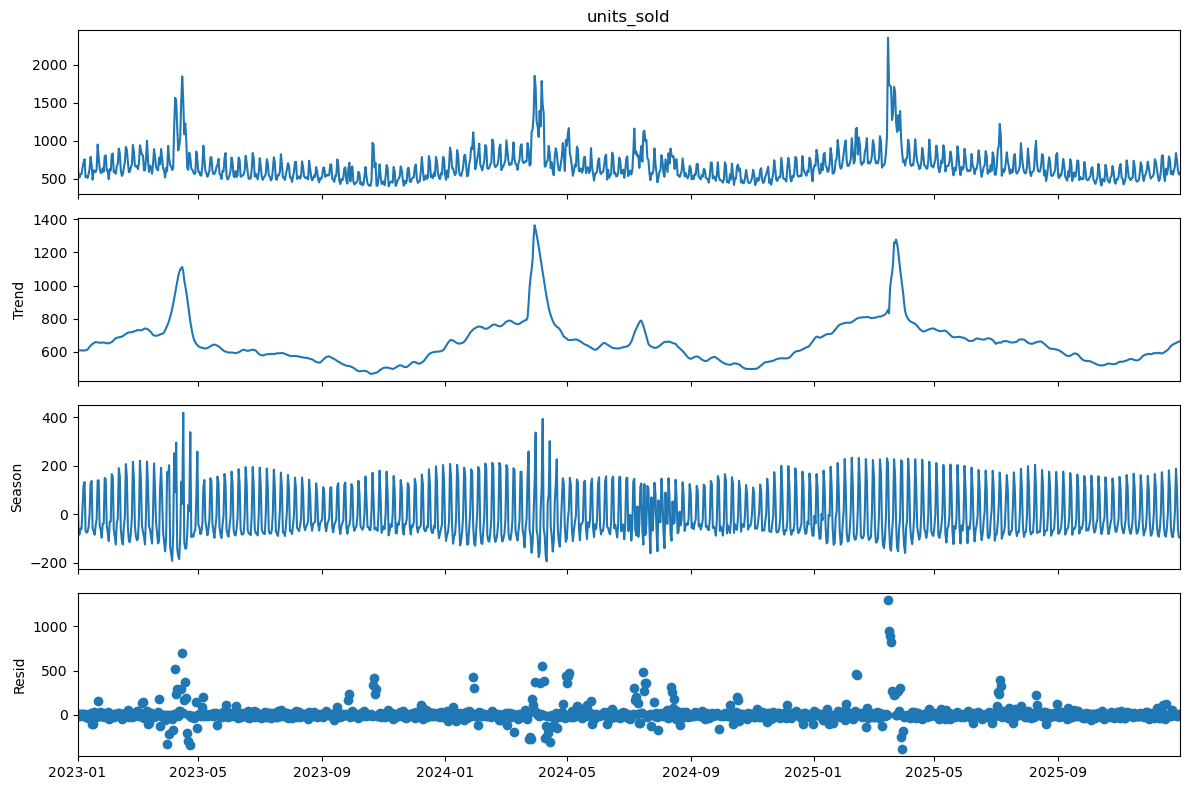

In [21]:
# STL decomposition with weekly seasonality.
stl = STL(y, period=7, robust=True).fit()
fig = stl.plot()
fig.set_size_inches(12, 8)
plt.tight_layout()
plt.show()


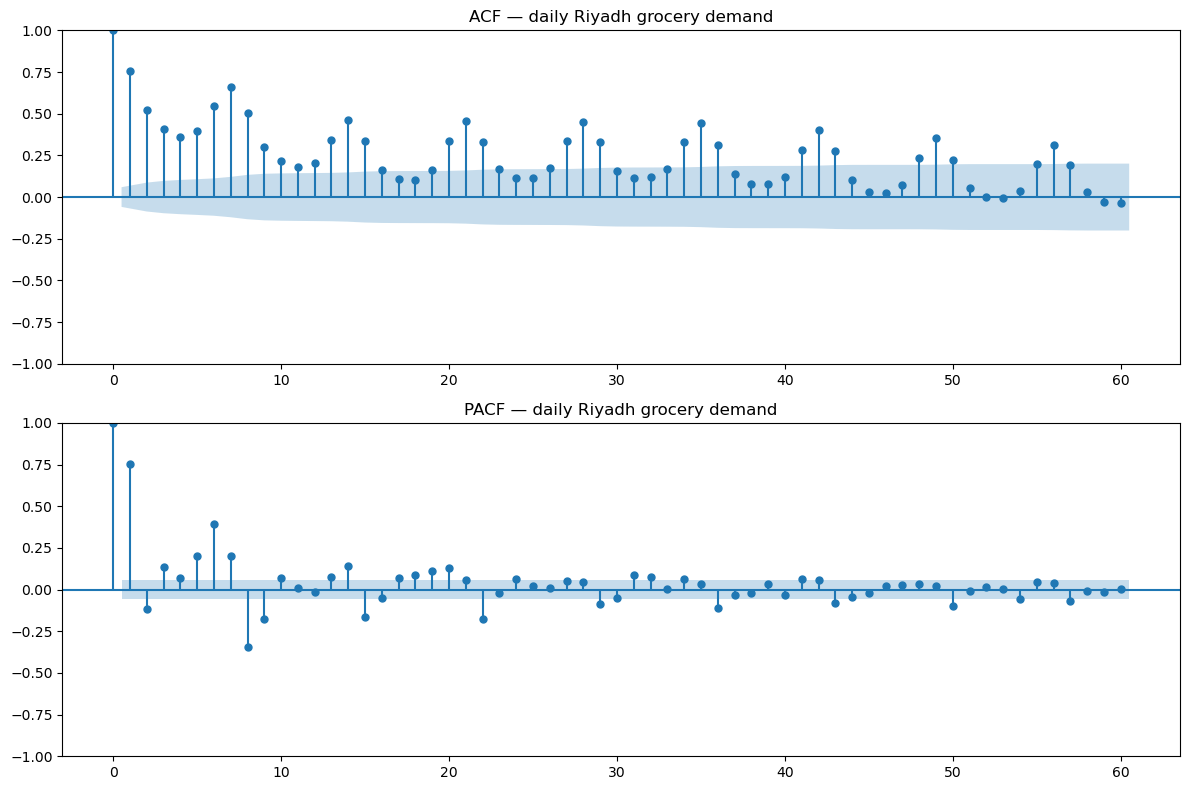

ADF statistic (level): -3.8721
ADF p-value (level): 0.002250
Interpretation: reject the unit-root null at the 5% level; the level series is consistent with stationarity.


In [22]:
# ACF/PACF: inspect short and weekly lags.
fig, axes = plt.subplots(2, 1, figsize=(12, 8))
plot_acf(y.dropna(), lags=min(60, len(y)//3), ax=axes[0], alpha=0.05)
axes[0].set_title("ACF — daily Riyadh grocery demand")
plot_pacf(y.dropna(), lags=min(60, len(y)//3), ax=axes[1], alpha=0.05, method="ywm")
axes[1].set_title("PACF — daily Riyadh grocery demand")
plt.tight_layout()
plt.show()

adf_level = adfuller(y.dropna(), autolag="AIC")
print(f"ADF statistic (level): {adf_level[0]:.4f}")
print(f"ADF p-value (level): {adf_level[1]:.6f}")

if adf_level[1] < 0.05:
    print("Interpretation: reject the unit-root null at the 5% level; the level series is consistent with stationarity.")
    y_model = y.copy()
    d_order = 0
else:
    print("Interpretation: fail to reject the unit-root null at the 5% level; differencing is indicated before a non-seasonal ARIMA component.")
    y_model = y.diff().dropna()
    d_order = 1
    adf_diff = adfuller(y_model, autolag="AIC")
    print(f"ADF p-value after first difference: {adf_diff[1]:.6f}")


### Diagnostic interpretation

The ADF p-value is used as a stationarity decision point rather than being reported without interpretation. The weekly STL component and ACF spikes around lag 7 are evidence to inspect weekly seasonality explicitly. Any differencing decision is carried into the classical-model specification instead of being chosen arbitrarily.

## 2. Classical Forecasting Model — SARIMA

In [23]:
# Initial holdout for a clean out-of-sample comparison.
HOLDOUT = min(28, max(14, len(y)//10))
train_classical = y.iloc[:-HOLDOUT]
test_classical = y.iloc[-HOLDOUT:]

# Parsimonious weekly SARIMA. d follows the ADF diagnostic above.
ORDER = (1, d_order, 1)
SEASONAL_ORDER = (1, 0, 1, 7)
print("SARIMA order:", ORDER)
print("Seasonal order:", SEASONAL_ORDER)

sarima = SARIMAX(
    train_classical,
    order=ORDER,
    seasonal_order=SEASONAL_ORDER,
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

classical_pred = sarima.forecast(HOLDOUT)
mae_classical = mean_absolute_error(test_classical, classical_pred)
rmse_classical = np.sqrt(mean_squared_error(test_classical, classical_pred))

print(f"SARIMA holdout MAE: {mae_classical:.3f}")
print(f"SARIMA holdout RMSE: {rmse_classical:.3f}")

resid = sarima.resid.dropna()
lb = acorr_ljungbox(resid, lags=[7, 14], return_df=True)
print("\nLjung-Box residual diagnostic:")
display(lb)


SARIMA order: (1, 0, 1)
Seasonal order: (1, 0, 1, 7)
SARIMA holdout MAE: 28.991
SARIMA holdout RMSE: 38.732

Ljung-Box residual diagnostic:


,lb_stat,lb_pvalue
7,15.799043,0.027017
14,31.592719,0.004575


## 3. ML/GBM Forecasting & Temporal Feature Engineering

In [24]:
LAGS = [1, 2, 3, 7, 14, 21, 28]
ROLL_WINDOWS = [7, 14, 28]

def make_features(series):
    out = pd.DataFrame({"y": series})
    for lag in LAGS:
        out[f"lag_{lag}"] = series.shift(lag)
    for w in ROLL_WINDOWS:
        shifted = series.shift(1)
        out[f"rolling_mean_{w}"] = shifted.rolling(w).mean()
        out[f"rolling_std_{w}"] = shifted.rolling(w).std()
    out["day_of_week"] = series.index.dayofweek
    out["is_weekend"] = (series.index.dayofweek >= 5).astype(int)
    out["day_of_month"] = series.index.day
    out["month"] = series.index.month
    out["week_of_year"] = series.index.isocalendar().week.astype(int).values
    return out

features = make_features(y).dropna()
feature_cols = [c for c in features.columns if c != "y"]
print("Feature rows:", len(features))
print("Features:", feature_cols)


Feature rows: 1068
Features: ['lag_1', 'lag_2', 'lag_3', 'lag_7', 'lag_14', 'lag_21', 'lag_28', 'rolling_mean_7', 'rolling_std_7', 'rolling_mean_14', 'rolling_std_14', 'rolling_mean_28', 'rolling_std_28', 'day_of_week', 'is_weekend', 'day_of_month', 'month', 'week_of_year']


In [25]:
# One-step-ahead GBM training on the historical feature table.
# The final backtest below refits the model inside each fold to preserve time order.
gbm = HistGradientBoostingRegressor(
    max_iter=300, learning_rate=0.05, max_leaf_nodes=15,
    l2_regularization=1.0, random_state=SEED
)
gbm.fit(features[feature_cols], features["y"])

last_row = features.iloc[[-1]]
print("GBM trained on", len(features), "leakage-safe feature rows.")


GBM trained on 1068 leakage-safe feature rows.


## 4. Walk-Forward Backtesting — 4 Expanding Folds

In [26]:
def make_feature_row(history, date):
    s = history
    row = {}
    for lag in LAGS:
        row[f"lag_{lag}"] = s.iloc[-lag]
    for w in ROLL_WINDOWS:
        vals = s.iloc[-w:]
        row[f"rolling_mean_{w}"] = vals.mean()
        row[f"rolling_std_{w}"] = vals.std()
    row["day_of_week"] = date.dayofweek
    row["is_weekend"] = int(date.dayofweek >= 5)
    row["day_of_month"] = date.day
    row["month"] = date.month
    row["week_of_year"] = int(date.isocalendar().week)
    return pd.DataFrame([row], index=[date])[feature_cols]

def recursive_gbm_forecast(train_series, horizon):
    train_feat = make_features(train_series).dropna()
    model = HistGradientBoostingRegressor(
        max_iter=300, learning_rate=0.05, max_leaf_nodes=15,
        l2_regularization=1.0, random_state=SEED
    )
    model.fit(train_feat[feature_cols], train_feat["y"])
    history = train_series.copy()
    preds = []
    for _ in range(horizon):
        next_date = history.index[-1] + pd.Timedelta(days=1)
        x_next = make_feature_row(history, next_date)
        pred = float(model.predict(x_next)[0])
        preds.append(pred)
        history.loc[next_date] = pred
    return pd.Series(preds, index=history.index[-horizon:])

H = 7
N_FOLDS = 4
min_train = max(60, len(y) - N_FOLDS * H - 1)
fold_rows = []

for fold in range(N_FOLDS):
    train_end = min_train + fold * H
    train = y.iloc[:train_end]
    test = y.iloc[train_end:train_end + H]
    if len(test) < H:
        break
    pred = recursive_gbm_forecast(train, H)
    fold_rows.append({
        "fold": fold + 1,
        "train_end": train.index[-1],
        "test_start": test.index[0],
        "test_end": test.index[-1],
        "MAE": mean_absolute_error(test, pred),
        "RMSE": np.sqrt(mean_squared_error(test, pred)),
    })

backtest_results = pd.DataFrame(fold_rows)
display(backtest_results)
print("Number of completed folds:", len(backtest_results))


,fold,train_end,test_start,test_end,MAE,RMSE
0,1,2025-12-02,2025-12-03,2025-12-09,34.789203,46.826107
1,2,2025-12-09,2025-12-10,2025-12-16,49.127615,56.049739
2,3,2025-12-16,2025-12-17,2025-12-23,40.469470,50.811998
3,4,2025-12-23,2025-12-24,2025-12-30,28.753796,30.007733


Number of completed folds: 4


## 5. Accuracy Metrics

In [27]:
def mase(actual, forecast, insample, m=7):
    actual = np.asarray(actual)
    forecast = np.asarray(forecast)
    insample = np.asarray(insample)
    scale = np.mean(np.abs(insample[m:] - insample[:-m]))
    return np.mean(np.abs(actual - forecast)) / scale if scale != 0 else np.nan

def wape(actual, forecast):
    actual = np.asarray(actual)
    forecast = np.asarray(forecast)
    denom = np.sum(np.abs(actual))
    return np.sum(np.abs(actual - forecast)) / denom if denom != 0 else np.nan

# Recompute fold predictions to report all requested metrics.
metric_rows = []
for fold in range(len(backtest_results)):
    train_end = min_train + fold * H
    train = y.iloc[:train_end]
    test = y.iloc[train_end:train_end + H]
    pred = recursive_gbm_forecast(train, H)
    metric_rows.append({
        "fold": fold + 1,
        "MAE": mean_absolute_error(test, pred),
        "RMSE": np.sqrt(mean_squared_error(test, pred)),
        "MASE": mase(test, pred, train, m=7),
        "WAPE": wape(test, pred) * 100,
    })

metrics_df = pd.DataFrame(metric_rows)
display(metrics_df)
print("\nMean across folds:")
display(metrics_df.drop(columns="fold").mean().to_frame("mean"))


,fold,MAE,RMSE,MASE,WAPE
0,1,34.789203,46.826107,0.390542,5.727291
1,2,49.127615,56.049739,0.553295,8.223178
2,3,40.469470,50.811998,0.456845,6.286868
3,4,28.753796,30.007733,0.325134,4.411058



Mean across folds:


,mean
MAE,38.285021
RMSE,45.923894
MASE,0.431454
WAPE,6.162099


## 6. Probabilistic Forecasting — Conformal Prediction Interval

Nominal coverage: 90%
Observed coverage: 100.00%
Mean interval width: 168.010 units


,actual,forecast,lower,upper
date,,,,
2025-12-18,553.0,572.630605,488.625649,656.635561
2025-12-19,625.0,581.558037,497.553080,665.562993
2025-12-20,793.0,738.617279,654.612323,822.622236
2025-12-21,746.0,730.727638,646.722681,814.732594
2025-12-22,559.0,551.189691,467.184735,635.194648
2025-12-23,599.0,525.163621,441.158665,609.168578
2025-12-24,550.0,564.628543,480.623586,648.633499
2025-12-25,605.0,573.720103,489.715147,657.725060
2025-12-26,667.0,597.552392,513.547435,681.557348


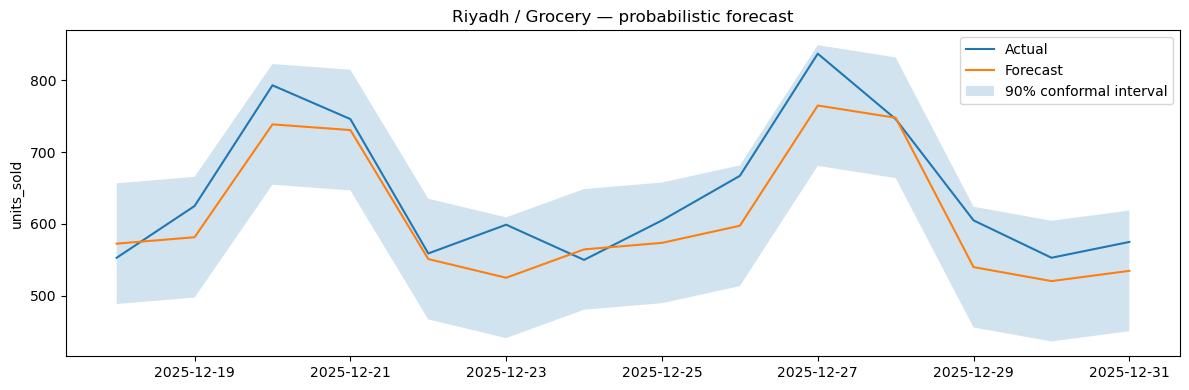

In [29]:
# Chronological split: training -> calibration -> future test.
interval_h = min(14, max(7, len(y)//12))
cal_size = min(28, max(14, len(y)//8))
origin = len(y) - interval_h
cal_end = origin
cal_start = cal_end - cal_size

cal_series = y.iloc[:cal_start]
cal_actual = y.iloc[cal_start:cal_end]
future_actual = y.iloc[origin:origin + interval_h]

# Calibrate one-step residuals without using future test observations.
cal_feat = make_features(cal_series).dropna()
cal_model = HistGradientBoostingRegressor(max_iter=300, learning_rate=0.05, max_leaf_nodes=15, l2_regularization=1.0, random_state=SEED)
cal_model.fit(cal_feat[feature_cols], cal_feat["y"])

hist = cal_series.copy()
cal_preds = []
for dt in cal_actual.index:
    x = make_feature_row(hist, dt)
    pred = float(cal_model.predict(x)[0])
    cal_preds.append(pred)
    hist.loc[dt] = cal_actual.loc[dt]

abs_errors = np.abs(cal_actual.values - np.array(cal_preds))
q = np.quantile(abs_errors, 0.90, method="higher")

# Point forecasts for the future horizon using only information available at the origin.
future_pred = recursive_gbm_forecast(y.iloc[:origin], interval_h)
lower = future_pred - q
upper = future_pred + q

nominal = 0.90
coverage = np.mean((future_actual.values >= lower.values) & (future_actual.values <= upper.values))
interval_width = np.mean(upper.values - lower.values)

print(f"Nominal coverage: {nominal:.0%}")
print(f"Observed coverage: {coverage:.2%}")
print(f"Mean interval width: {interval_width:.3f} units")

interval_df = pd.DataFrame({"actual": future_actual, "forecast": future_pred, "lower": lower, "upper": upper})
display(interval_df)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(interval_df.index, interval_df["actual"], label="Actual")
ax.plot(interval_df.index, interval_df["forecast"], label="Forecast")
ax.fill_between(interval_df.index, interval_df["lower"], interval_df["upper"], alpha=0.2, label="90% conformal interval")
ax.set_title("Riyadh / Grocery — probabilistic forecast")
ax.set_ylabel("units_sold")
ax.legend()
plt.tight_layout()
plt.show()


## 7. Model Comparison & Deployment Recommendation

The deployment decision is based on more than error numbers. The relevant axes are **history length, interpretability, interval support, and compute budget**.

| Decision axis | SARIMA | GBM with temporal features |
|---|---|---|
| History length | Works well with a coherent, sufficiently long seasonal history | Benefits from enough historical examples to learn nonlinear lag/calendar effects |
| Interpretability | Parameters and seasonal structure are comparatively transparent | Feature importance/response is useful, but the model is less directly interpretable |
| Interval support | Can provide model-based intervals through the fitted state-space model | Conformal calibration provides practical distribution-free intervals |
| Compute budget | Repeated refits can be comparatively expensive for large parameter searches | Training is generally efficient for tabular temporal features; recursive forecasting adds prediction steps |

**Recommendation for this series:** use the backtest results together with the four decision axes above. If operational simplicity and an explicit weekly seasonal structure are the priority, the SARIMA family is straightforward to maintain. If nonlinear interactions between lagged demand and calendar effects materially improve repeated walk-forward performance, the GBM is a strong operational alternative. The final choice should therefore be tied to the observed backtest table, interval behavior, and the deployment constraints rather than selecting a model solely because it has the lowest single error value.
